<a href="https://colab.research.google.com/github/Adhithyan6/Deep-Learning-Techniques/blob/master/GAN/GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Device: cuda


100%|██████████| 170M/170M [00:03<00:00, 43.7MB/s]


Epoch  10 | D_loss: 1.1046 | G_loss: 1.5642
Epoch  20 | D_loss: 1.1840 | G_loss: 1.2321
Epoch  30 | D_loss: 1.1772 | G_loss: 1.2485
Epoch  40 | D_loss: 1.0855 | G_loss: 1.3522
Epoch  50 | D_loss: 1.0116 | G_loss: 1.4960


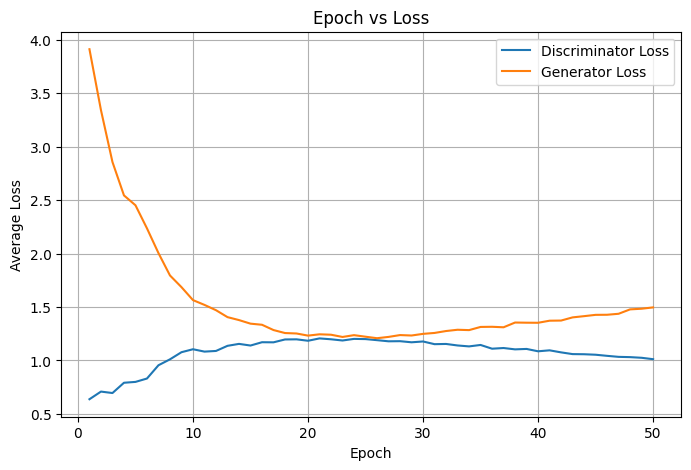

Saved generator and discriminator weights.


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
import numpy as np
import os
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

seed = 999
random.seed(seed)
torch.manual_seed(seed)

dataroot = "./data"
image_size = 32          # CIFAR-10 images are 32x32
nc = 3                   # number of channels (RGB)
nz = 100                 # size of latent vector (z)
ngf = 64                 # generator feature map size
ndf = 64                 # discriminator feature map size
num_epochs = 50          # train for 50 epochs
batch_size = 128
lr = 0.0002
beta1 = 0.5

os.makedirs(dataroot, exist_ok=True)

transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5,)*3, (0.5,)*3)  # map to [-1,1]
])

dataset = datasets.CIFAR10(root=dataroot, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

class Generator(nn.Module):
    def __init__(self, nz, ngf, nc):
        super().__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf*8, 4, 1, 0, bias=False),  # (ngf*8) x 4 x 4
            nn.BatchNorm2d(ngf*8),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf*8, ngf*4, 4, 2, 1, bias=False),  # (ngf*4) x 8 x 8
            nn.BatchNorm2d(ngf*4),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),  # (ngf*2) x 16 x 16
            nn.BatchNorm2d(ngf*2),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False),    # (ngf) x 32 x 32
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, nc, 3, 1, 1, bias=False),       # nc x 32 x 32
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

class Discriminator(nn.Module):
    def __init__(self, nc, ndf):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),   # ndf x 16 x 16
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf*2, 4, 2, 1, bias=False),  # (ndf*2) x 8 x 8
            nn.BatchNorm2d(ndf*2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1, bias=False),  # (ndf*4) x 4 x 4
            nn.BatchNorm2d(ndf*4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf*4, 1, 4, 1, 0, bias=False),  # 1 x 1 x 1
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input).view(-1)

netG = Generator(nz, ngf, nc).to(device)
netG.apply(weights_init)

netD = Discriminator(nc, ndf).to(device)
netD.apply(weights_init)

criterion = nn.BCELoss()
fixed_noise = torch.randn(64, nz, 1, 1, device=device)

real_label = 1.
fake_label = 0.

optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

G_losses = []
D_losses = []
epochs_list = []

print_progress = lambda epoch, d_loss, g_loss: print(f"Epoch {epoch:3d} | D_loss: {d_loss:.4f} | G_loss: {g_loss:.4f}")

for epoch in range(1, num_epochs + 1):
    running_d_loss = 0.0
    running_g_loss = 0.0
    batches = 0

    for i, data in enumerate(dataloader, 0):
        batches += 1
        real_images = data[0].to(device)
        b_size = real_images.size(0)

        netD.zero_grad()
        label = torch.full((b_size,), real_label, dtype=torch.float, device=device)
        output_real = netD(real_images)
        errD_real = criterion(output_real, label)
        errD_real.backward()

        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake = netG(noise)
        label.fill_(fake_label)
        output_fake = netD(fake.detach())
        errD_fake = criterion(output_fake, label)
        errD_fake.backward()

        errD = errD_real + errD_fake
        optimizerD.step()

        netG.zero_grad()
        label.fill_(real_label)
        output = netD(fake)
        errG = criterion(output, label)
        errG.backward()
        optimizerG.step()

        running_d_loss += errD.item()
        running_g_loss += errG.item()

    avg_d = running_d_loss / batches
    avg_g = running_g_loss / batches
    D_losses.append(avg_d)
    G_losses.append(avg_g)
    epochs_list.append(epoch)

    if epoch % 10 == 0:
        print_progress(epoch, avg_d, avg_g)

plt.figure(figsize=(8, 5))
plt.plot(epochs_list, D_losses, label='Discriminator Loss')
plt.plot(epochs_list, G_losses, label='Generator Loss')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('Epoch vs Loss')
plt.legend()
plt.grid(True)
plt.show()

torch.save(netG.state_dict(), "dcgan_generator.pth")
torch.save(netD.state_dict(), "dcgan_discriminator.pth")
print("Saved generator and discriminator weights.")
